# ECE 143 Final Project Setup


## Data Source
- https://huggingface.co/datasets/d0r1h/customer_churn


## Research Question
- TBD


## Initial Preprocessing Steps 
| Feature Category | Action Taken | Reason |
|:---|:---|:---|
| **Target Variable** | Filtered `churn_risk_score >= 0` | Removes invalid -1 placeholders to ensure clean model training. |
| **Noise Reduction** | Dropped `security_no`, `referral_id`, `last_visit_time` | Removes unique IDs and timestamps that cause overfitting. |
| **Outlier Handling** | Replaced `-999` in `days_since_last_login` and clipped negatives in `avg_time_spent` | Corrects data entry bugs found in raw HuggingFace data. |
| **Missing Values** | Imputed with **Median** | Handles `?` and `NaN` entries in numeric columns like `points_in_wallet`. |
| **New Features** | Created `tenure_days` | Converts `joining_date` into a numeric measure of customer relationship length. |
| **Encoding** | LabelEncoded `feedback`, `membership_category`, `complaint_status` | Converts high-signal text categories into math-ready formats for Random Forest. |
| **Engagement** | Included `avg_frequency_login_days` | Captures the "heartbeat" of customer activity (key churn predictor). |


In [ ]:
# Imports
import numpy as np
import pandas as pd
from datetime import datetime
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from pathlib import Path

In [9]:
df = pd.read_csv("hf://datasets/d0r1h/customer_churn/churn.csv")
print(df.columns)
print(df.head(2))

Index(['age', 'gender', 'security_no', 'region_category',
       'membership_category', 'joining_date', 'joined_through_referral',
       'referral_id', 'preferred_offer_types', 'medium_of_operation',
       'internet_option', 'last_visit_time', 'days_since_last_login',
       'avg_time_spent', 'avg_transaction_value', 'avg_frequency_login_days',
       'points_in_wallet', 'used_special_discount',
       'offer_application_preference', 'past_complaint', 'complaint_status',
       'feedback', 'churn_risk_score'],
      dtype='object')
   age gender security_no region_category  membership_category joining_date  \
0   18      F     XW0DQ7H         Village  Platinum Membership   17-08-2017   
1   32      F     5K0N3X1            City   Premium Membership   28-08-2017   

  joined_through_referral referral_id  preferred_offer_types  \
0                      No    xxxxxxxx  Gift Vouchers/Coupons   
1                       ?    CID21329  Gift Vouchers/Coupons   

  medium_of_operation  ... av

In [ ]:
Path("../data/raw").mkdir(parents=True, exist_ok=True)
df.to_csv("../data/raw/customer_churn.csv", index=False)

In [14]:
def preprocess_hf_dataset(df):
    '''
    Prepares the Hugging Face churn dataset with strict type validation.
    
    Parameters:
        df (pd.DataFrame): Raw dataframe from the HF source.
        
    Returns:
        pd.DataFrame: Processed features and target variable.
    '''
    assert isinstance(df, pd.DataFrame), "Input must be a pandas DataFrame"
    assert 'churn_risk_score' in df.columns, "Target column 'churn_risk_score' is missing"

    df = df.copy()
    df = df[df['churn_risk_score'] >= 0] 

    noise = ['security_no', 'referral_id', 'last_visit_time']
    df = df.drop(columns=[c for c in noise if c in df.columns], errors='ignore')

    # Data Cleaning
    df.replace(['?', 'xxxxxxxx'], np.nan, inplace=True)
    df['days_since_last_login'] = pd.to_numeric(df['days_since_last_login'], errors='coerce')
    # Treat -999 as NaN, then fill with median
    df.loc[df['days_since_last_login'] < 0, 'days_since_last_login'] = np.nan
    df['days_since_last_login'] = df['days_since_last_login'].fillna(df['days_since_last_login'].median())

    # Time Stuff
    df['joining_date'] = pd.to_datetime(df['joining_date'], format='mixed', errors='coerce')
    # Fill missing dates with the most common date so tenure isn't NaN
    df['joining_date'] = df['joining_date'].fillna(df['joining_date'].mode()[0])
    reference_date = df['joining_date'].max()
    df['tenure_days'] = (reference_date - df['joining_date']).dt.days

    binary_map = {'Yes': 1, 'No': 0}
    binary_cols = ['used_special_discount', 'offer_application_preference', 'past_complaint', 'joined_through_referral']
    for col in binary_cols:
        if col in df.columns:
            df[col] = df[col].map(binary_map).fillna(0)

    # Number Values
    numeric_cols = ['avg_time_spent', 'avg_transaction_value', 'points_in_wallet', 'age', 'avg_frequency_login_days']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].clip(lower=0)  # Neutralize negative value bugs
        df[col] = df[col].fillna(df[col].median())

    # Categorical Encoding
    encoder = LabelEncoder()
    categorical_cols = ['membership_category', 'feedback', 'complaint_status', 'region_category', 'gender']
    for col in categorical_cols:
        df[col] = encoder.fit_transform(df[col].astype(str))

    # replaced with tenure
    df = df.drop(columns=['joining_date'], errors='ignore')

    return df

In [17]:
def plot_importance(df):
    '''
    Generates a feature importance bar chart using a Random Forest classifier.
    Includes behavioral and friction metrics for a more accurate churn profile.
    '''
    features = [
        'age', 'tenure_days', 'points_in_wallet', 'avg_transaction_value', 
        'avg_time_spent', 'membership_category', 'feedback', 
        'days_since_last_login', 'avg_frequency_login_days', 
        'past_complaint', 'complaint_status'
    ]
    
    # Ensure only columns existing in the df are used 
    features = [f for f in features if f in df.columns]
    
    X = df[features]
    y = df['churn_risk_score']

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X, y)

    importance_data = pd.DataFrame({
        'Feature': features,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    
    ax = sns.barplot(
        x='Importance', 
        y='Feature', 
        data=importance_data, 
        hue='Feature', 
        palette='viridis', 
        legend=False
    )
    
    # Add value labels to the end of each bar for clarity
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=5)
    
    plt.title('Feature Importance: Key Drivers of Customer Churn Risk', fontsize=14, pad=15)
    plt.xlabel('Importance Score (Predictive Contribution)', fontsize=12)
    plt.ylabel('Customer Metric', fontsize=12)
    
    plt.tight_layout()
    plt.show()

File successfully saved to: ..\data\processed\customer_churn_features.csv


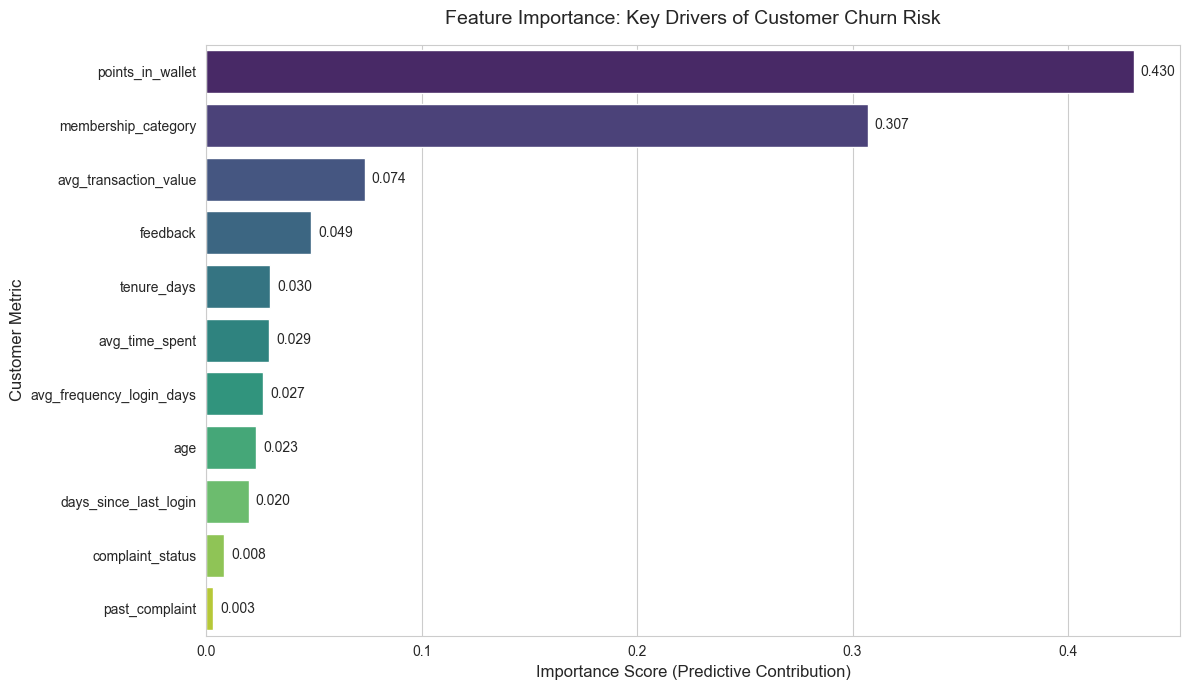

In [18]:
df_clean = preprocess_hf_dataset(df)
output_path = Path("../data/processed/customer_churn_features.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)
df_clean.to_csv(output_path, index=False)

print(f"File successfully saved to: {output_path}")

# Visualize
plot_importance(df_clean)